In [27]:
import numpy as np
import matplotlib.pyplot as plt

In [28]:
from dotenv import load_dotenv
load_dotenv()

True

In [29]:
# Load documents from the "crew_data" directory

from langchain_community.document_loaders import PyPDFLoader
import os

docs = []

file_path = "crew_data/doc.pdf"

loader = PyPDFLoader(file_path)
docs = loader.load()

print("Pages loaded:", len(docs))

Pages loaded: 6


In [30]:
# Chunk the documents into smaller pieces

from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=80
)

chunks = text_splitter.split_documents(docs)

chunks = [c for c in chunks if len(c.page_content.strip()) > 50]

print("Clean chunks:", len(chunks))

Clean chunks: 56


In [31]:
# Create Embeddings + FAISS Vectorstore

from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

vectorstore = FAISS.from_documents(chunks, embeddings)

print("Vectorstore created")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4844.34it/s]


Vectorstore created


In [32]:
# TEST RETRIEVAL

query = "What is clinical summarization?"

results = vectorstore.similarity_search(query, k=3)

for i, doc in enumerate(results):
    print("\nResult", i+1)
    print(doc.page_content[:500])


Result 1
unstructured across thousands of progress notes, lab results, office visits, phone call transcriptions, and the like. Clinical
summarization involves condensing this unstructured information into an accurate picture of a patient’s medical history
and current health status into a concise, accessible format. This practice has significant implications for healthcare
professionals, patient health outcomes, and hospital expenditures. However, even in a strictly regulated industry that is

Result 2
American healthcare, clinicians have diverse ways of approaching clinical summarization – with many placing much
time, energy, and value, while others not so much.
Tools that streamline the clinical summarization process have been a hot topic of debate, with many arguing for its
effectiveness in healthcare delivery while others fear issues in data privacy, ethical considerations, and more. This

Result 3
the aforementioned issues in clinical summarization using AI agents. Several case st

In [33]:
queries = [
    "What is AI in healthcare?",
    "How does summarization work?",
    "What are clinical workflows?",
    "What is generative AI used for?"
]

for q in queries:
    print("\n\nQUERY:", q)
    results = vectorstore.similarity_search(q, k=2)

    for i, doc in enumerate(results):
        print("\n-", doc.page_content[:300])



QUERY: What is AI in healthcare?

- Future developments in this field must focus on refining AI technologies, improving their adaptability, and ensuring
they align with the overarching goal of improving patient outcomes.
As AI continues to evolve, future research will likely explore more sophisticated models that can handle a wider
ra

- socioeconomic bias in AI algorithms and the impact of automation on employment within the healthcare sector, will
need to be carefully considered.
References
[1] O’Malley AS, Cohen GR, Grossman JM. Electronic medical records and communication with patients and other
clinicians: are we talking less? 


QUERY: How does summarization work?

- unstructured across thousands of progress notes, lab results, office visits, phone call transcriptions, and the like. Clinical
summarization involves condensing this unstructured information into an accurate picture of a patient’s medical history
and current health status into a concise, accessible 

- the aforemen

In [34]:
# Create embeddings manually to check dimensions

embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

vectors = [
    embedding_model.embed_query(chunk.page_content)
    for chunk in chunks
]

vectors = np.array(vectors)

print("Embedding shape:", vectors.shape)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5922.29it/s]


Embedding shape: (56, 384)


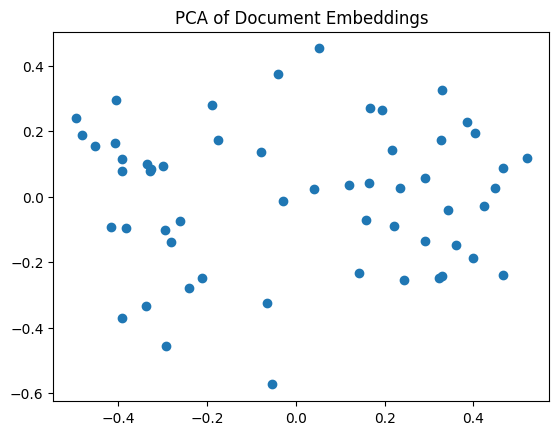

In [35]:
# PCA Visualization of the embeddings

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

plt.figure()
plt.scatter(reduced[:, 0], reduced[:, 1])
plt.title("PCA of Document Embeddings")
plt.show()

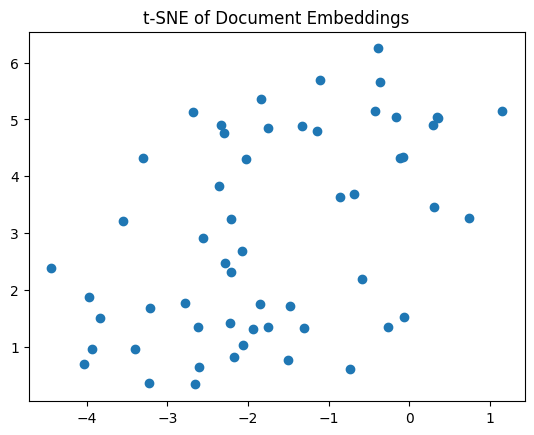

In [36]:
# t-SNE Visualization of the embeddings

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
reduced_tsne = tsne.fit_transform(vectors)

plt.figure()
plt.scatter(reduced_tsne[:, 0], reduced_tsne[:, 1])
plt.title("t-SNE of Document Embeddings")
plt.show()

Task 2

In [37]:
# Run the Crew to execute the task

from langchain_groq import ChatGroq
import os

llm = ChatGroq(
    groq_api_key=os.getenv("GROQ_API_KEY"),
    model_name="llama-3.1-8b-instant"   # strong + fast
)

In [38]:
#  Split Existing PDF Into Multiple Logical Documents

from langchain_core.documents import Document

new_docs = []

for doc in docs:
    lines = doc.page_content.split("\n")  # split by single line breaks
    
    buffer = ""
    for line in lines:
        line = line.strip()
        
        if len(line) == 0:
            continue
        
        buffer += " " + line
        
        # create a new doc every ~300 chars
        if len(buffer) > 300:
            new_docs.append(Document(page_content=buffer.strip(), metadata={"source": "doc.pdf"}))
            buffer = ""

    # catch remaining text
    if len(buffer) > 50:
        new_docs.append(Document(page_content=buffer.strip(), metadata={"source": "doc.pdf"}))

print("Simulated new docs:", len(new_docs))


# Chunk again
chunks = text_splitter.split_documents(new_docs)
chunks = [c for c in chunks if len(c.page_content.strip()) > 50]

print("Chunks after splitting:", len(chunks))

Simulated new docs: 71
Chunks after splitting: 71


In [39]:
# Rebuild FAISS Vectorstore with new chunks 

vectorstore = FAISS.from_documents(chunks, embeddings)
print("Vectorstore rebuilt")

Vectorstore rebuilt


In [40]:
# Create a RetrievalQA chain

from langchain_classic.chains import RetrievalQA

# Create retriever
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

# Create QA chain
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    retriever=retriever
)

# Test full RAG pipeline
response = qa_chain.run("What is clinical summarization?")
print(response)

Clinical summarization is the process of condensing and organizing large amounts of clinical information from patient records, medical notes, and other sources into a concise, easily understandable format. The goal of clinical summarization is to extract key information, identify relevant data, and present it in a way that is useful for healthcare professionals to make informed decisions about patient care.

Clinical summarization can involve summarizing:

1. Patient history and medical conditions
2. Medications and treatment plans
3. Lab results and test findings
4. Progress notes and communication with other healthcare providers

Effective clinical summarization can help healthcare professionals quickly identify important information, reduce errors, and improve patient outcomes. It can also help reduce the time and effort required to review patient records, freeing up time for more critical tasks.


In [41]:
#  Test retrieval again with new chunks

queries = [
    "What is clinical summarization?",
    "How is AI used in healthcare?",
    "What are challenges in clinical workflows?",
    "Examples of AI in medical applications"
]

for q in queries:
    print("\nQUERY:", q)
    results = vectorstore.similarity_search(q, k=2)
    
    for doc in results:
        print("-", doc.page_content[:300])


QUERY: What is clinical summarization?
- and current health status into a concise, accessible format. This practice has significant implications for healthcare professionals, patient health outcomes, and hospital expenditures. However, even in a strictly regulated industry that is American healthcare, clinicians have diverse ways of approa
- the aforementioned issues in clinical summarization using AI agents. Several case studies verify AI usage in various clinical settings to aid in chart review and summarization of clinical information. 3

QUERY: How is AI used in healthcare?
- Future developments in this field must focus on refining AI technologies, improving their adaptability, and ensuring they align with the overarching goal of improving patient outcomes. As AI continues to evolve, future research will likely explore more sophisticated models that can handle a wider ra
- socioeconomic bias in AI algorithms and the impact of automation on employment within the healthcare sector, 

In [16]:
# Test the RAG chain with multiple questions

questions = [
    "Explain clinical summarization in simple terms",
    "What are benefits of AI in clinical summarization?",
    "What challenges exist in healthcare AI?",
    "How does AI improve clinical workflows?"
]

for q in questions:
    print("\nQ:", q)
    print("A:", qa_chain.run(q))


Q: Explain clinical summarization in simple terms
A: Clinical summarization is the process of taking a large amount of unorganized medical information about a patient (such as notes from doctors, lab results, and past visits) and making it concise and easy to understand.

Think of it like summarizing a long book into a few key points. In the case of clinical summarization, the "book" is the patient's entire medical history, and the "key points" are the most important things that doctors and other healthcare professionals need to know to provide the best care for the patient.

This helps healthcare professionals quickly see a patient's overall health status, medical history, and any issues they may be experiencing. It also helps reduce errors and ensures that patients receive the best possible care.

Q: What are benefits of AI in clinical summarization?
A: According to the context, the benefits of AI in clinical summarization include:

1. Improving clinical accuracy and reliability thr

Task 3

In [42]:
# Load environment variables

load_dotenv()

TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [43]:
# Get real-time data from Tavily

from tavily import TavilyClient

tavily = TavilyClient(api_key=TAVILY_API_KEY)

response = tavily.search(query="latest AI trends 2026")

# Extract top 3 results
results = response["results"][:3]

trends_text = ""

for i, r in enumerate(results):
    trends_text += f"{i+1}. {r['content']}\n\n"

print("=== RAW TAVILY DATA ===\n")
print(trends_text)

=== RAW TAVILY DATA ===

1. 1. The AI bubble will deflate, and the economy will suffer. · 2. More all-in adopters will create 'AI factories' and infrastructure. · 3. GenAI

2. 4 Skills I'm Learning that AI Can't Replace (backed by data). Jeff Su · 100K views ; AI Trends 2026: Quantum, Agentic AI & Smarter Automation. IBM

3. Seven AI trends to watch in 2026 will make AI a true partner — boosting teamwork, security, research momentum and infrastructure efficiency.




Task 4

In [44]:
# Create Writer Agent to summarize trends

from crewai import Agent

writer_agent = Agent(
    role="AI Report Writer",
    goal="Write a structured report on AI trends",
    backstory="Expert in summarizing AI research into clear reports.",
    llm="groq/llama-3.1-8b-instant",
    verbose=False
)

In [45]:
# Create Task for the Writer Agent to generate the report based on Tavily data

from crewai import Task

task = Task(
    description=f"""
    Based ONLY on the data below, extract 3 AI trends.

    DATA:
    {trends_text}

    Rules:
    - Do NOT add new information
    - Do NOT infer beyond the text
    - Keep it factual and short

    Format:

    # AI Trends Report (2026)

    ## Key Trends
    - Trend 1
    - Trend 2
    - Trend 3

    ## Summary
    2 sentences only
    """,
    expected_output="Clean markdown report",
    agent=writer_agent
)

In [46]:
# Run the Crew to execute the task

from crewai import Crew

crew = Crew(
    agents=[writer_agent],
    tasks=[task],
    verbose=False
)

result = crew.kickoff()

print("\n=== FINAL REPORT ===\n")
print(result.raw)


=== FINAL REPORT ===

# AI Trends Report (2026)

## Key Trends
- The AI bubble will deflate, and the economy will suffer.
- More all-in adopters will create 'AI factories' and infrastructure.
- The emergence of GenAI.

## Summary
The AI trends in 2026 indicate a shift in the adoption and application of AI technologies, with a focus on establishing infrastructure and potentially experiencing economic repercussions. These trends suggest a significant transformation in the role of AI in various industries and sectors.


In [47]:
# Save the result to a markdown file

with open("ai_trends_report.md", "w") as f:
    f.write(result.raw)

print("✅ Report saved as ai_trends_report.md")

✅ Report saved as ai_trends_report.md
